# Task 4 — Statistical Modeling & Risk-Based Pricing

**Objective:** Build, evaluate, and interpret predictive models for AlphaCare Insurance Solutions (ACIS) to predict claim probability and claim severity, and integrate them into a dynamic, risk-based pricing framework.

## Modeling Roadmap
1. **Claim Severity Model (Regression):** Predict `TotalClaims` for policies where a claim occurred (`TotalClaims > 0`). Estimates the financial liability.
2. **Claim Probability Model (Classification):** Predict `HasClaim` (binary: 0/1) for all policies. Estimates the claim propensity.
3. **Premium Optimization (Pricing Framework):** Dynamic pricing combining both models:
   $$\text{Premium} = (P(\text{claim}) \times \text{Predicted Severity}) \times (1 + \text{Expense Loading} + \text{Profit Margin})$$

In [1]:
import sys, os
import warnings
warnings.filterwarnings('ignore')

# Add project root to path so we can import src modules
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split

from src.modeling import (
    engineer_features, prepare_modeling_data,
    train_regressors, train_classifiers,
    evaluate_regressors, evaluate_classifiers,
    calculate_risk_based_premium, calibrate_probability
)

pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

print('Imports loaded ✓')

Imports loaded ✓


## 1. Load Data

In [2]:
df = pd.read_csv('../data/cleaned_insurance_data.csv', low_memory=False)
print(f'Full dataset shape: {df.shape}')
df.head(3)

Full dataset shape: (1000098, 52)


,UnderwrittenCoverID,PolicyID,TransactionMonth,IsVATRegistered,Citizenship,LegalType,Title,Language,Bank,AccountType,MaritalStatus,Gender,Country,Province,PostalCode,MainCrestaZone,SubCrestaZone,ItemType,mmcode,VehicleType,RegistrationYear,make,Model,Cylinders,cubiccapacity,kilowatts,bodytype,NumberOfDoors,VehicleIntroDate,CustomValueEstimate,AlarmImmobiliser,TrackingDevice,CapitalOutstanding,NewVehicle,WrittenOff,Rebuilt,Converted,CrossBorder,NumberOfVehiclesInFleet,SumInsured,TermFrequency,CalculatedPremiumPerTerm,ExcessSelected,CoverCategory,CoverType,CoverGroup,Section,Product,StatutoryClass,StatutoryRiskType,TotalPremium,TotalClaims
0,145249,12827,2015-03-01,True,NaN,Close Corporation,Mr,English,First National Bank,Current account,NaN,NaN,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0000,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0000,2597.0000,130.0000,S/D,4.0000,6/2002,119300.0000,Yes,No,119300.0000,More than 6 months,Unknown,Unknown,Unknown,0.0000,0.0000,0.0100,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.9298,0.0000
1,145249,12827,2015-05-01,True,NaN,Close Corporation,Mr,English,First National Bank,Current account,NaN,NaN,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0000,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0000,2597.0000,130.0000,S/D,4.0000,6/2002,119300.0000,Yes,No,119300.0000,More than 6 months,Unknown,Unknown,Unknown,0.0000,0.0000,0.0100,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,21.9298,0.0000
2,145249,12827,2015-07-01,True,NaN,Close Corporation,Mr,English,First National Bank,Current account,NaN,NaN,South Africa,Gauteng,1459,Rand East,Rand East,Mobility - Motor,44069150.0000,Passenger Vehicle,2004,MERCEDES-BENZ,E 240,6.0000,2597.0000,130.0000,S/D,4.0000,6/2002,119300.0000,Yes,No,119300.0000,More than 6 months,Unknown,Unknown,Unknown,0.0000,0.0000,0.0100,Monthly,25.0000,Mobility - Windscreen,Windscreen,Windscreen,Comprehensive - Taxi,Motor Comprehensive,Mobility Metered Taxis: Monthly,Commercial,IFRS Constant,0.0000,0.0000


## 2. Downsampling & Subset Preparation

The full dataset has ~1 million rows, but only 2,788 claims (~0.28% claim rate).
To ensure efficient training, memory safety, and stable models:
- **Severity Model:** Trained only on the 2,788 claim rows.
- **Probability Model:** Trained on a downsampled subset containing all 2,788 claim rows plus a random sample of 50,000 non-claim rows, representing a balanced claim-density representation.

In [3]:
# Severity dataset (claims occurred)
df_severity = df[df['TotalClaims'] > 0].copy()
print(f'Severity dataset shape: {df_severity.shape}')

# Classification dataset (downsampled negatives + all positives)
df_pos = df[df['TotalClaims'] > 0].copy()
df_neg = df[df['TotalClaims'] == 0].sample(n=50000, random_state=42).copy()
df_class = pd.concat([df_pos, df_neg]).sample(frac=1.0, random_state=42).reset_index(drop=True)
df_class['HasClaim'] = (df_class['TotalClaims'] > 0).astype(int)
print(f'Classification dataset shape: {df_class.shape} (Claim rate: {df_class["HasClaim"].mean():.2%})')

Severity dataset shape: (2788, 52)


Classification dataset shape: (52788, 53) (Claim rate: 5.28%)


## 3. Feature Selection

In [4]:
# Select a comprehensive set of predictor features
features = [
    'IsVATRegistered', 'Citizenship', 'LegalType', 'MaritalStatus', 'Gender', 'Province',
    'VehicleType', 'make', 'Cylinders', 'cubiccapacity', 'kilowatts', 'bodytype',
    'AlarmImmobiliser', 'TrackingDevice', 'NewVehicle', 'WrittenOff', 'Rebuilt', 'Converted',
    'CrossBorder', 'SumInsured', 'TermFrequency', 'VehicleAge'
]
print(f'Features selected for modeling ({len(features)}): {features}')

Features selected for modeling (22): ['IsVATRegistered', 'Citizenship', 'LegalType', 'MaritalStatus', 'Gender', 'Province', 'VehicleType', 'make', 'Cylinders', 'cubiccapacity', 'kilowatts', 'bodytype', 'AlarmImmobiliser', 'TrackingDevice', 'NewVehicle', 'WrittenOff', 'Rebuilt', 'Converted', 'CrossBorder', 'SumInsured', 'TermFrequency', 'VehicleAge']


## 4. Claim Severity Prediction (Regression)

Estimates expected claim sizes when a claim occurs.

In [5]:
print('Fitting common encoder and imputers on full dataset...')
_, _, _, _, _, common_encoder, common_cat_imputer, common_num_imputer = prepare_modeling_data(
    df, 'TotalClaims', features, is_regression=True, test_size=0.3, random_state=42
)

print('Preparing severity modeling data using common encoder...')
X_train_reg, X_test_reg, y_train_reg, y_test_reg, _, encoder_reg, cat_imp_reg, num_imp_reg = prepare_modeling_data(
    df_severity, 'TotalClaims', features, is_regression=True, test_size=0.3, random_state=42,
    encoder=common_encoder, cat_imputer=common_cat_imputer, num_imputer=common_num_imputer
)
print(f'Train features shape: {X_train_reg.shape} | Test features shape: {X_test_reg.shape}')

Fitting common encoder and imputers on full dataset...


Preparing severity modeling data using common encoder...
Train features shape: (1951, 22) | Test features shape: (837, 22)


In [6]:
print('Training severity models (Linear Regression, Random Forest, XGBoost)...')
reg_models = train_regressors(X_train_reg, y_train_reg)
print('Training complete ✓')

Training severity models (Linear Regression, Random Forest, XGBoost)...
Training complete ✓


In [7]:
print('Evaluating severity models on Test Set...')
reg_results = evaluate_regressors(reg_models, X_test_reg, y_test_reg)
reg_results

Evaluating severity models on Test Set...


,Model,RMSE,R2
0,Linear Regression,39385.1897,0.0148
1,Random Forest,34002.9453,0.2657
2,XGBoost,34946.8495,0.2244


## 5. Claim Probability Prediction (Classification)

Estimates probability of a policy incurring a claim.

In [8]:
print('Preparing probability modeling data using common encoder...')
X_train_cls, X_test_cls, y_train_cls, y_test_cls, _, encoder_cls, cat_imp_cls, num_imp_cls = prepare_modeling_data(
    df_class, 'HasClaim', features, is_regression=False, test_size=0.3, random_state=42,
    encoder=common_encoder, cat_imputer=common_cat_imputer, num_imputer=common_num_imputer
)
print(f'Train features shape: {X_train_cls.shape} | Test features shape: {X_test_cls.shape}')

Preparing probability modeling data using common encoder...
Train features shape: (36951, 22) | Test features shape: (15837, 22)


In [9]:
print('Training probability models (Logistic Regression, Random Forest, XGBoost)...')
cls_models = train_classifiers(X_train_cls, y_train_cls)
print('Training complete ✓')

Training probability models (Logistic Regression, Random Forest, XGBoost)...


Training complete ✓


In [10]:
print('Evaluating probability models on Test Set...')
cls_results = evaluate_classifiers(cls_models, X_test_cls, y_test_cls)
cls_results

Evaluating probability models on Test Set...


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.9472,0.0000,0.0000,0.0000
1,Random Forest,0.8116,0.1728,0.6782,0.2754
2,XGBoost,0.7434,0.1622,0.9270,0.2761


## 6. Premium Optimization (Pricing Framework)

Combine the best classifiers and regressors to calculate optimal, risk-based premiums:
$$\text{Premium} = (P(\text{claim}) \times \text{Predicted Severity}) \times (1 + \text{Expense Loading} + \text{Profit Margin})$$
We set expense loading to 20% and profit margin to 10% (30% total loading).

In [11]:
best_reg = reg_models['XGBoost']
best_cls = cls_models['XGBoost']

# 1. P(claim)
p_claim_raw = best_cls.predict_proba(X_test_cls)[:, 1]

# Calibrate the predicted probabilities using the prior correction formula
population_rate = 2788 / 1000098
sample_rate = len(df_pos) / len(df_class)
p_claim = calibrate_probability(p_claim_raw, population_rate, sample_rate, is_weighted=True)

# 2. Severity prediction (clamped to positive values)
pred_sev = best_reg.predict(X_test_cls)
pred_sev = np.maximum(pred_sev, 0.0)

# 3. Compute dynamic risk-based premium
risk_premium = calculate_risk_based_premium(p_claim, pred_sev, expense_loading=0.20, profit_margin=0.10)

# 4. Map back to original test dataset
_, test_idx = train_test_split(df_class.index, test_size=0.3, random_state=42, stratify=df_class['HasClaim'])
df_test = df_class.loc[test_idx].copy()
df_test['RiskBasedPremium'] = risk_premium

print('Premium stats comparison (Calculated vs Risk-Based):')
print(df_test[['TotalPremium', 'CalculatedPremiumPerTerm', 'RiskBasedPremium']].describe())

Premium stats comparison (Calculated vs Risk-Based):
       TotalPremium  CalculatedPremiumPerTerm  RiskBasedPremium
count    15837.0000                15837.0000        15837.0000
mean        79.1567                  133.8231           83.9076
std        547.8513                  635.7097          246.7958
min       -294.7868                    0.0002            0.0000
25%          0.0000                    3.5123            0.3475
50%          2.4606                   18.0000            0.6277
75%         43.8596                   90.0000           25.0827
max      65282.6034                74422.1679        13589.1074


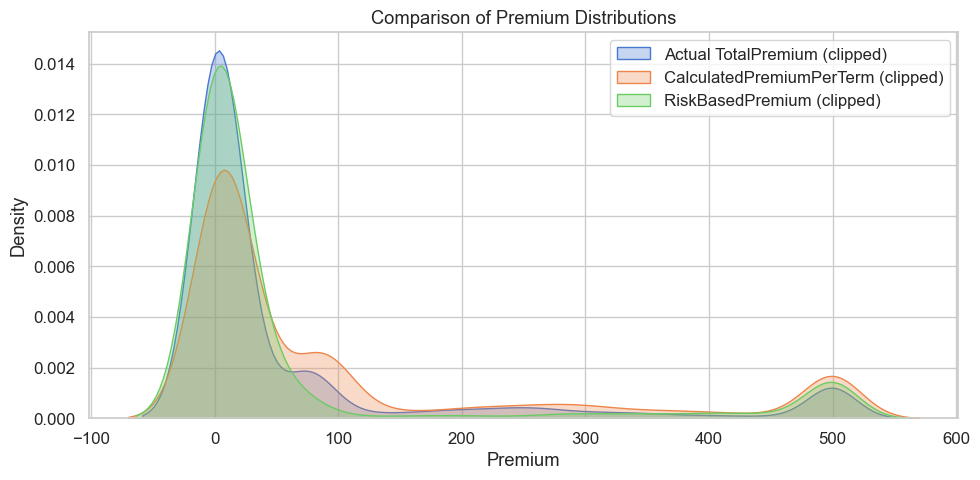

In [12]:
# Plot the distributions of actual, calculated, and risk-based premiums
fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(df_test['TotalPremium'].clip(0, 500), label='Actual TotalPremium (clipped)', ax=ax, fill=True, alpha=0.3)
sns.kdeplot(df_test['CalculatedPremiumPerTerm'].clip(0, 500), label='CalculatedPremiumPerTerm (clipped)', ax=ax, fill=True, alpha=0.3)
sns.kdeplot(df_test['RiskBasedPremium'].clip(0, 500), label='RiskBasedPremium (clipped)', ax=ax, fill=True, alpha=0.3)
ax.set_title('Comparison of Premium Distributions')
ax.set_xlabel('Premium')
ax.legend()
plt.tight_layout()
os.makedirs('../reports', exist_ok=True)
plt.savefig('../reports/premium_distribution_comparison.png')
plt.show()

## 7. Model Interpretability (SHAP)

Analyze the top features driving our XGBoost claim probability classifier.

Computing SHAP values for the best XGBoost classifier...


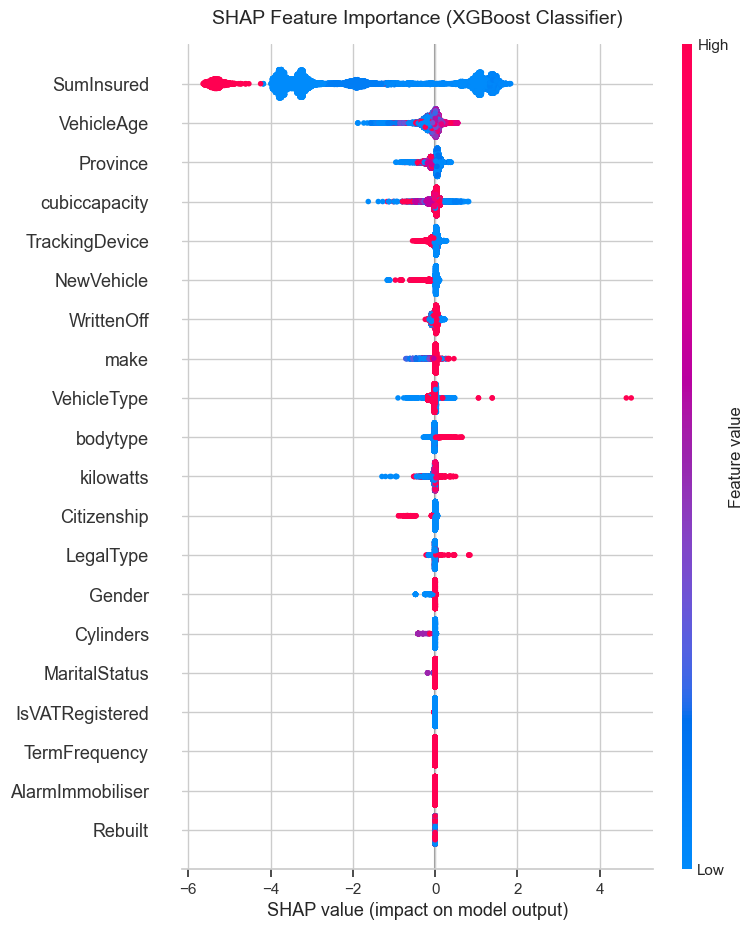

In [13]:
print('Computing SHAP values for the best XGBoost classifier...')
explainer = shap.TreeExplainer(best_cls)
shap_values = explainer(X_test_cls)

# SHAP Summary Plot
fig = plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_cls, feature_names=features, show=False)
plt.title('SHAP Feature Importance (XGBoost Classifier)', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('../reports/shap_feature_importance.png')
plt.show()

## 8. Export Results

In [14]:
reg_results.to_csv('../reports/severity_model_comparison.csv', index=False)
cls_results.to_csv('../reports/probability_model_comparison.csv', index=False)
print('Results successfully saved to reports/ ✓')

Results successfully saved to reports/ ✓
